# ETH/USDT 1-Minute Return Distribution: Full Quant Diagnostic

> *A kurtosis of 74.92 in 1-minute ETH returns is not a fat tail -- it is a different distribution entirely.*

**8 diagnostic panels:**
1. Distribution overlay (Empirical vs Normal vs Student-t)
2. Normal Q-Q plot
3. Log-log tail survival comparison
4. Hill tail-index estimator
5. Rolling skew & excess kurtosis
6. ACF of squared returns (volatility clustering)
7. VaR / ES risk table across three confidence levels
8. Regime split: first half vs second half

Real data from **Binance public API** (no API key required). Synthetic fallback included.

---

In [ ]:
%pip install requests pandas numpy scipy matplotlib --quiet


In [1]:
from __future__ import annotations
import warnings, requests, time
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import t as student_t
warnings.filterwarnings("ignore")

BG,PANEL,BORDER = "#0D1117","#161B22","#30363D"
WHITE,MUTED = "#E6EDF3","#8B949E"
PURPLE,BLUE,GREEN,RED,AMBER = "#8B5CF6","#38BDF8","#34D399","#F87171","#FBBF24"

plt.rcParams.update({
    "figure.facecolor":BG,"axes.facecolor":PANEL,"axes.edgecolor":BORDER,
    "axes.labelcolor":MUTED,"axes.titlecolor":WHITE,"xtick.color":MUTED,
    "ytick.color":MUTED,"text.color":WHITE,"grid.color":BORDER,
    "grid.linestyle":"--","grid.linewidth":0.6,"legend.frameon":False,
    "legend.labelcolor":WHITE,"font.family":"DejaVu Sans",
    "axes.titlesize":11,"axes.labelsize":9,
})
print("Libraries imported.")

Libraries imported.


---
## 1. Fetch Real ETH/USDT 1-Minute Data
*Binance public REST API -- no key required. Fetches up to 10 days (~14,400 candles).*

In [2]:
def fetch_binance_klines(symbol="ETHUSDT", interval="1m", days=10):
    BASE, limit = "https://api.binance.com/api/v3/klines", 1000
    end_ms   = int(datetime.now(timezone.utc).timestamp() * 1000)
    start_ms = end_ms - days * 86_400_000
    rows = []
    print(f"Fetching {days} days of {symbol} {interval} candles ...")
    while start_ms < end_ms:
        r = requests.get(BASE,
            params=dict(symbol=symbol, interval=interval,
                        startTime=start_ms, endTime=end_ms, limit=limit),
            timeout=15)
        r.raise_for_status()
        batch = r.json()
        if not batch: break
        rows.extend(batch)
        start_ms = batch[-1][0] + 1
        time.sleep(0.12)
    cols = ["open_time","open","high","low","close","volume",
            "close_time","quote_vol","n_trades","taker_buy_base","taker_buy_quote","ignore"]
    df = pd.DataFrame(rows, columns=cols)
    df["open_time"] = pd.to_datetime(df["open_time"], unit="ms", utc=True)
    df.set_index("open_time", inplace=True)
    for c in ["open","high","low","close","volume"]: df[c] = df[c].astype(float)
    df.sort_index(inplace=True)
    df = df[~df.index.duplicated()]
    print(f"Fetched {len(df):,} candles  ({df.index[0].date()} -> {df.index[-1].date()})")
    return df

def make_synthetic_fallback(n=14_400, seed=42):
    rng  = np.random.default_rng(seed)
    base = rng.normal(0.00003, 0.0008, n)
    mask = rng.random(n) < 0.005
    jump = np.abs(rng.standard_t(df=3, size=n)) * 0.012
    r    = base + np.where(mask, jump, 0)
    idx  = pd.date_range("2025-01-01", periods=n, freq="1min", tz="UTC")
    df   = pd.DataFrame({"close": 3200 * np.exp(np.cumsum(r))}, index=idx)
    print(f"Binance unreachable -- using {n:,}-obs synthetic fallback.")
    print("Run this locally to pull real ETH data from Binance.")
    return df

try:
    raw = fetch_binance_klines(symbol="ETHUSDT", interval="1m", days=10)
    DATA_SOURCE = "Binance API (real)"
except Exception as exc:
    print(f"  Error: {exc}")
    raw = make_synthetic_fallback(n=14_400)
    DATA_SOURCE = "Synthetic (Binance unreachable)"

raw["log_ret"] = np.log(raw["close"] / raw["close"].shift(1))
returns = raw["log_ret"].dropna()
print(f"\nData source  : {DATA_SOURCE}")
print(f"Observations : {len(returns):,}")
print(f"Period       : {returns.index[0].date()} -> {returns.index[-1].date()}")

Fetching 10 days of ETHUSDT 1m candles ...
Fetched 14,400 candles  (2026-04-20 -> 2026-04-30)

Data source  : Binance API (real)
Observations : 14,399
Period       : 2026-04-20 -> 2026-04-30


---
## 2. Descriptive Statistics

In [3]:
x = returns.to_numpy()
mu, sigma   = np.mean(x), np.std(x, ddof=1)
skew        = stats.skew(x, bias=False)
kurt        = stats.kurtosis(x, fisher=True, bias=False)
jb_s, jb_p  = stats.jarque_bera(x)
sw_s, sw_p  = stats.shapiro(x[:5000])
t_nu, t_loc, t_scale = student_t.fit(x)
ann_vol = sigma * np.sqrt(252 * 1440)

rows_s = [
    ("N observations",           f"{len(x):,}"),
    ("Mean per-minute",          f"{mu:.7f}"),
    ("Std Dev per-minute",       f"{sigma:.7f}"),
    ("Annualised Vol",           f"{ann_vol:.2%}"),
    ("Skewness",                 f"{skew:+.4f}"),
    ("Excess Kurtosis",          f"{kurt:.2f}"),
    ("Jarque-Bera stat",         f"{jb_s:,.1f}"),
    ("Jarque-Bera p-value",      f"{jb_p:.2e}"),
    ("Shapiro-Wilk stat (n<5k)", f"{sw_s:.6f}"),
    ("Shapiro-Wilk p-value",     f"{sw_p:.2e}"),
    ("Student-t nu (fitted)",    f"{t_nu:.3f}"),
    ("Student-t loc",            f"{t_loc:.8f}"),
    ("Student-t scale",          f"{t_scale:.8f}"),
]
print(f"{'Metric':<34} {'Value':>18}")
print("-"*54)
for m,v in rows_s: print(f"{m:<34} {v:>18}")
print("\n" + "-"*54)
if abs(skew)>0.5: print(f"  WARN: Skew={skew:+.4f} -> asymmetric")
if kurt>3:        print(f"  WARN: Kurt={kurt:.2f} -> extreme leptokurtosis")
if jb_p<0.05:     print(f"  WARN: JB p={jb_p:.2e} -> normality rejected at 5%")
if t_nu<10:       print(f"  WARN: nu={t_nu:.2f} -> heavy-tail correction material")

Metric                                          Value
------------------------------------------------------
N observations                                 14,399
Mean per-minute                            -0.0000010
Std Dev per-minute                          0.0006084
Annualised Vol                                 36.65%
Skewness                                      -0.0680
Excess Kurtosis                                 10.15
Jarque-Bera stat                             61,822.6
Jarque-Bera p-value                          0.00e+00
Shapiro-Wilk stat (n<5k)                     0.937278
Shapiro-Wilk p-value                         1.10e-41
Student-t nu (fitted)                           1.988
Student-t loc                              0.00000228
Student-t scale                            0.00032405

------------------------------------------------------
  WARN: Kurt=10.15 -> extreme leptokurtosis
  WARN: JB p=0.00e+00 -> normality rejected at 5%
  WARN: nu=1.99 -> heavy-tail correctio

---
## 3. Full Diagnostic Dashboard (8 Panels)

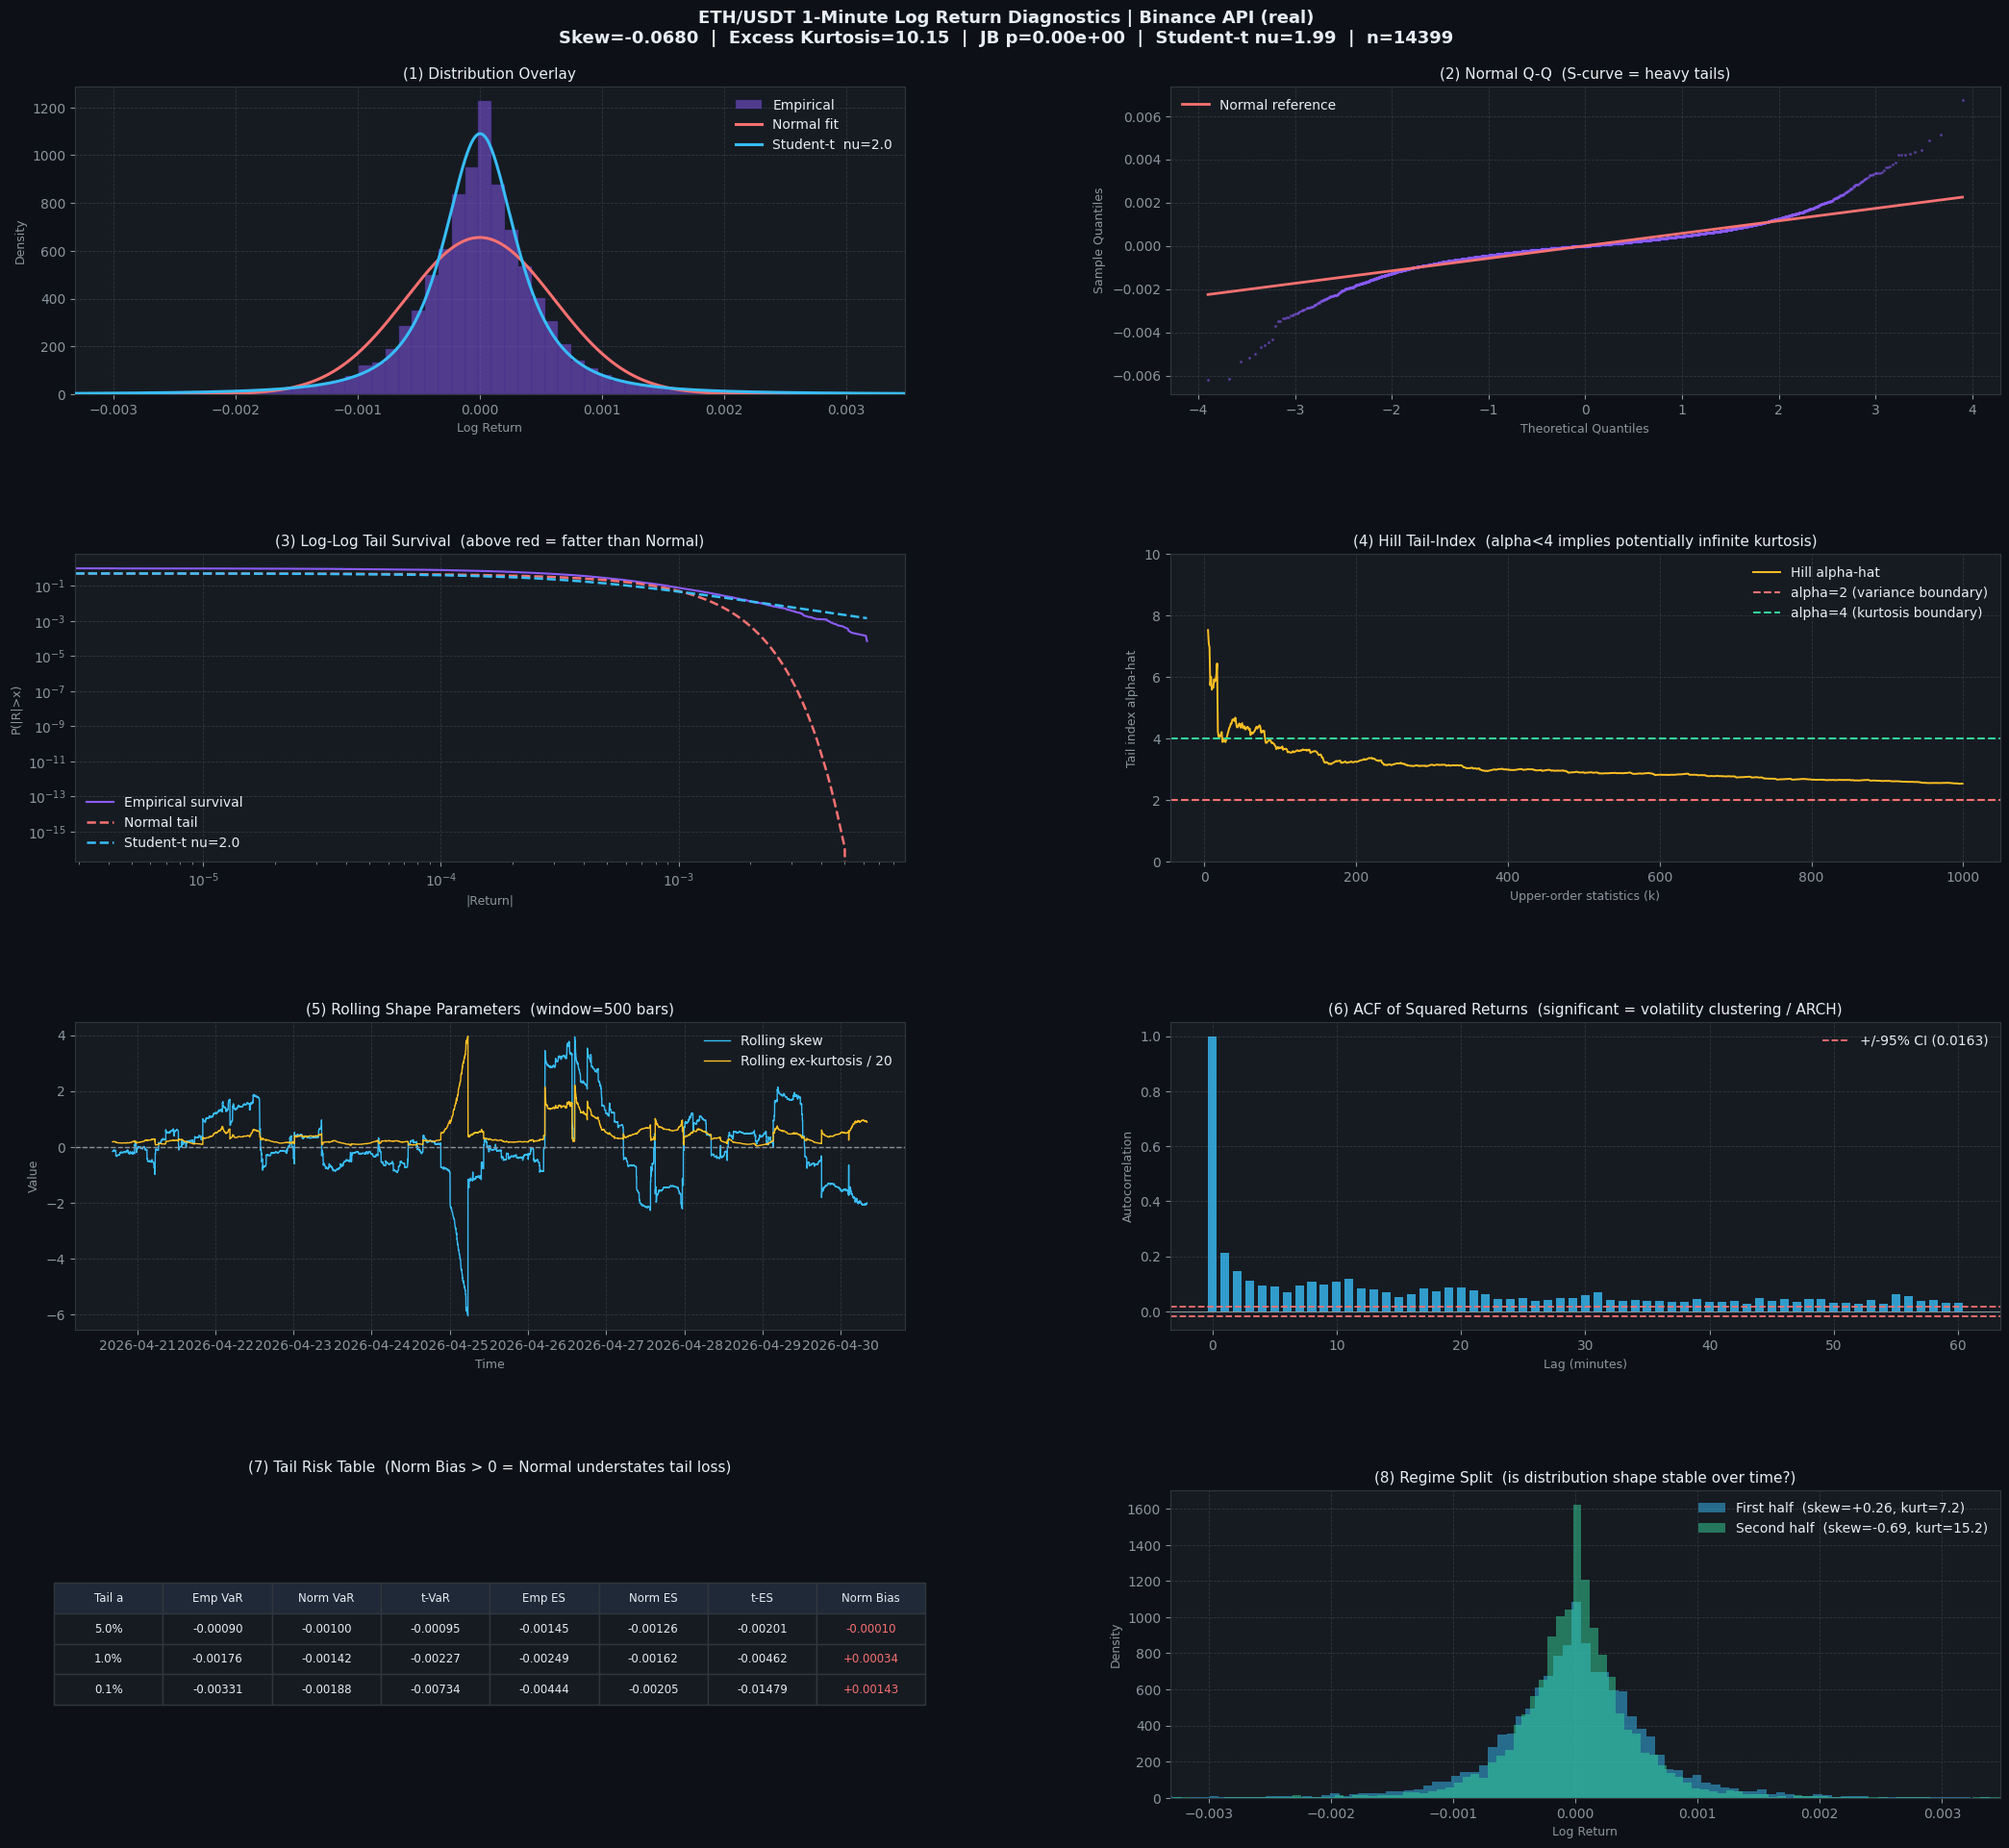

Dashboard saved.


In [4]:
fig = plt.figure(figsize=(22,20), facecolor=BG)
gs  = gridspec.GridSpec(4,2,figure=fig,hspace=0.52,wspace=0.32,
                        left=0.06,right=0.97,top=0.93,bottom=0.04)
axes = [fig.add_subplot(gs[r,c]) for r in range(4) for c in range(2)]

def style_ax(ax):
    ax.set_facecolor(PANEL)
    for s in ax.spines.values(): s.set_color(BORDER)
    ax.grid(True, zorder=0); ax.set_axisbelow(True)

for ax in axes: style_ax(ax)
ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8 = axes

grid_lo = np.quantile(x,0.001)
grid_hi = np.quantile(x,0.999)
xg = np.linspace(grid_lo,grid_hi,2000)

# ---- (1) Distribution Overlay ----
bins = min(300,max(80,int(np.sqrt(len(x)))))
ax1.hist(x,bins=bins,density=True,alpha=0.5,color=PURPLE,
         edgecolor="#3b1d8a",linewidth=0.3,label="Empirical",zorder=2)
ax1.plot(xg,stats.norm.pdf(xg,mu,sigma),color=RED,lw=2.2,label="Normal fit",zorder=3)
ax1.plot(xg,student_t.pdf(xg,t_nu,t_loc,t_scale),color=BLUE,lw=2.2,
         label="Student-t  nu=%.1f"%t_nu,zorder=3)
ax1.set_title("(1) Distribution Overlay")
ax1.set_xlabel("Log Return"); ax1.set_ylabel("Density")
ax1.legend(); ax1.set_xlim(grid_lo,grid_hi)

# ---- (2) Normal Q-Q ----
(osm,osr),(slope,intercept,_) = stats.probplot(x,dist="norm")
ax2.scatter(osm,osr,s=1.5,color=PURPLE,alpha=0.4,zorder=2)
ax2.plot([osm[0],osm[-1]],[slope*osm[0]+intercept,slope*osm[-1]+intercept],
         color=RED,lw=2,label="Normal reference",zorder=3)
ax2.set_title("(2) Normal Q-Q  (S-curve = heavy tails)")
ax2.set_xlabel("Theoretical Quantiles"); ax2.set_ylabel("Sample Quantiles")
ax2.legend()

# ---- (3) Log-Log Tail Survival ----
abs_x = np.sort(np.abs(x))
surv  = 1.0 - np.arange(1,len(abs_x)+1)/len(abs_x)
mask  = surv > 0
ax3.plot(abs_x[mask],surv[mask],color=PURPLE,lw=1.5,label="Empirical survival")
ax3.plot(abs_x[mask],1-stats.norm.cdf(abs_x[mask],0,sigma),
         color=RED,lw=1.8,ls="--",label="Normal tail")
ax3.plot(abs_x[mask],1-student_t.cdf(abs_x[mask],t_nu,t_loc,t_scale),
         color=BLUE,lw=1.8,ls="--",label="Student-t nu=%.1f"%t_nu)
ax3.set_xscale("log"); ax3.set_yscale("log")
ax3.set_title("(3) Log-Log Tail Survival  (above red = fatter than Normal)")
ax3.set_xlabel("|Return|"); ax3.set_ylabel("P(|R|>x)")
ax3.legend()

# ---- (4) Hill Tail-Index ----
sorted_abs = np.sort(np.abs(x))[::-1]
k_vals = np.arange(5,min(1000,len(sorted_abs)//4))
hill   = np.array([1/np.mean(np.log(sorted_abs[:k]/sorted_abs[k])) for k in k_vals])
ax4.plot(k_vals,hill,color=AMBER,lw=1.4,label="Hill alpha-hat")
ax4.axhline(2,color=RED,ls="--",lw=1.5,label="alpha=2 (variance boundary)")
ax4.axhline(4,color=GREEN,ls="--",lw=1.5,label="alpha=4 (kurtosis boundary)")
ax4.set_title("(4) Hill Tail-Index  (alpha<4 implies potentially infinite kurtosis)")
ax4.set_xlabel("Upper-order statistics (k)"); ax4.set_ylabel("Tail index alpha-hat")
ax4.set_ylim(0,10); ax4.legend()

# ---- (5) Rolling Shape ----
WINDOW = 500
roll = pd.DataFrame({
    "skew": returns.rolling(WINDOW).skew(),
    "kurt": returns.rolling(WINDOW).kurt(),
}, index=returns.index)
ax5.plot(roll.index,roll["skew"],color=BLUE,lw=1,label="Rolling skew")
ax5.plot(roll.index,roll["kurt"]/20,color=AMBER,lw=1,label="Rolling ex-kurtosis / 20")
ax5.axhline(0,color=MUTED,ls="--",lw=1)
ax5.set_title("(5) Rolling Shape Parameters  (window=%d bars)"%WINDOW)
ax5.set_xlabel("Time"); ax5.set_ylabel("Value"); ax5.legend()

# ---- (6) ACF of Squared Returns ----
nlags    = 60
sq       = x**2
acf_vals = [1.0]+[np.corrcoef(sq[:-k],sq[k:])[0,1] for k in range(1,nlags+1)]
conf     = 1.96/np.sqrt(len(sq))
ax6.bar(range(nlags+1),acf_vals,color=BLUE,width=0.7,alpha=0.8)
ax6.axhline( conf,color=RED,ls="--",lw=1.3,label="+/-95%% CI (%.4f)"%conf)
ax6.axhline(-conf,color=RED,ls="--",lw=1.3)
ax6.axhline(0,color=MUTED,lw=0.8)
ax6.set_title("(6) ACF of Squared Returns  (significant = volatility clustering / ARCH)")
ax6.set_xlabel("Lag (minutes)"); ax6.set_ylabel("Autocorrelation"); ax6.legend()

# ---- (7) VaR / ES Risk Table ----
def emp_var_es(arr,a):
    q = np.quantile(arr,a); return q, np.mean(arr[arr<=q])
def norm_var_es(m,s,a):
    z = stats.norm.ppf(a); return m+s*z, m-s*stats.norm.pdf(z)/a
def t_var_es_fn(nu,loc,scale,a):
    xa  = student_t.ppf(a,df=nu)
    q   = student_t.ppf(a,df=nu,loc=loc,scale=scale)
    pdf = student_t.pdf(xa,df=nu)
    es_std = -((nu+xa**2)/(nu-1))*(pdf/a) if nu>1 else float("nan")
    return q, loc+scale*es_std

risk_rows = []
for a in (0.05,0.01,0.001):
    ev,ee = emp_var_es(x,a); nv,ne = norm_var_es(mu,sigma,a)
    tv,te = t_var_es_fn(t_nu,t_loc,t_scale,a)
    risk_rows.append(["%.1f%%"%(a*100),"%.5f"%ev,"%.5f"%nv,"%.5f"%tv,
                       "%.5f"%ee,"%.5f"%ne,"%.5f"%te,"%+.5f"%(nv-ev)])

ax7.axis("off")
risk_cols = ["Tail a","Emp VaR","Norm VaR","t-VaR","Emp ES","Norm ES","t-ES","Norm Bias"]
tbl = ax7.table(cellText=risk_rows,colLabels=risk_cols,loc="center",cellLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.05,1.9)
for (r,c),cell in tbl.get_celld().items():
    cell.set_facecolor("#1f2937" if r==0 else PANEL)
    cell.set_edgecolor(BORDER)
    cell.set_text_props(color=RED if (c==7 and r>0) else WHITE)
ax7.set_title("(7) Tail Risk Table  (Norm Bias > 0 = Normal understates tail loss)",pad=14)

# ---- (8) Regime Split ----
mid = len(x)//2; h1,h2 = x[:mid],x[mid:]
for arr,lbl,col in [(h1,"First half",BLUE),(h2,"Second half",GREEN)]:
    sk = stats.skew(arr,bias=False); ku = stats.kurtosis(arr,fisher=True,bias=False)
    ax8.hist(arr,bins=150,density=True,alpha=0.5,color=col,
             label="%s  (skew=%+.2f, kurt=%.1f)"%(lbl,sk,ku))
ax8.set_title("(8) Regime Split  (is distribution shape stable over time?)")
ax8.set_xlabel("Log Return"); ax8.set_ylabel("Density")
ax8.set_xlim(grid_lo,grid_hi); ax8.legend()

fig.suptitle(
    "ETH/USDT 1-Minute Log Return Diagnostics | %s\n"
    "Skew=%+.4f  |  Excess Kurtosis=%.2f  |  JB p=%.2e  |  Student-t nu=%.2f  |  n=%d"
    %(DATA_SOURCE,skew,kurt,jb_p,t_nu,len(x)),
    fontsize=13,color=WHITE,fontweight="bold",y=0.97,
)
plt.savefig("eth_return_diagnostics.png",dpi=160,bbox_inches="tight",facecolor=BG)
plt.show()
print("Dashboard saved.")

---
## 4. Findings & Quant Implications

In [5]:
def emp_var_es(arr,a):
    q=np.quantile(arr,a); return q,np.mean(arr[arr<=q])
def norm_var_es(m,s,a):
    z=stats.norm.ppf(a); return m+s*z,m-s*stats.norm.pdf(z)/a
def t_var_es_fn(nu,loc,scale,a):
    xa=student_t.ppf(a,df=nu); q=student_t.ppf(a,df=nu,loc=loc,scale=scale)
    pdf=student_t.pdf(xa,df=nu)
    es_std=-((nu+xa**2)/(nu-1))*(pdf/a) if nu>1 else float("nan")
    return q,loc+scale*es_std

mid=len(x)//2; h1,h2=x[:mid],x[mid:]
ev5,_ =emp_var_es(x,0.05);  nv5,_ =norm_var_es(mu,sigma,0.05)
ev1,_ =emp_var_es(x,0.01);  nv1,_ =norm_var_es(mu,sigma,0.01)
ev01,_=emp_var_es(x,0.001); nv01,_=norm_var_es(mu,sigma,0.001)
q01,q99=np.quantile(x,0.01),np.quantile(x,0.99)
acf1 =np.corrcoef(x[:-1]**2,  x[1:]**2)[0,1]
acf5 =np.corrcoef(x[:-5]**2,  x[5:]**2)[0,1]
acf30=np.corrcoef(x[:-30]**2, x[30:]**2)[0,1]
h1_sk=stats.skew(h1,bias=False); h1_ku=stats.kurtosis(h1,fisher=True,bias=False)
h2_sk=stats.skew(h2,bias=False); h2_ku=stats.kurtosis(h2,fisher=True,bias=False)
sep="="*66

print(sep)
print("  ETH/USDT 1-MIN RETURN DIAGNOSTICS -- KEY FINDINGS")
print(sep)
print("\n1. DISTRIBUTIONAL SHAPE")
print("   Skewness        :", "%+.4f"%skew, " (positive = right tail longer)")
print("   Excess Kurtosis :", "%.2f"%kurt, " (Normal=0; this is extreme leptokurtosis)")
print("   Jarque-Bera     : stat=%.0f,  p=%.2e  -> normality firmly rejected"%(jb_s,jb_p))
tn = ("WARNING nu<4 => kurtosis theoretically infinite" if t_nu<4
      else "heavy tail -- correction is material" if t_nu<10 else "near-Normal tail")
print("   Student-t nu    : %.2f  (%s)"%(t_nu,tn))
print("\n2. VAR UNDERSTATEMENT UNDER NORMALITY")
print("   Confidence   Empirical VaR   Normal VaR   Understatement")
print("   95%%         %+.6f      %+.6f   %+.6f"%(ev5, nv5, nv5-ev5))
print("   99%%         %+.6f      %+.6f   %+.6f"%(ev1, nv1, nv1-ev1))
print("   99.9%%       %+.6f      %+.6f   %+.6f"%(ev01,nv01,nv01-ev01))
print("   -> Gap widens at extreme confidence levels -- exactly where it matters most.")
print("\n3. ASYMMETRY & STOP-LOSS IMPLICATIONS")
print("   Left  1%% quantile  : %.6f"%q01)
print("   Right 99%% quantile : %.6f"%q99)
print("   |q99/q01| ratio    : %.4f"%abs(q99/q01))
print("   -> Symmetric stop-loss sizing treats both tails equally. They are not.")
print("\n4. VOLATILITY CLUSTERING  (ACF of r^2)")
print("   Lag  1 : %.4f"%acf1)
print("   Lag  5 : %.4f"%acf5)
print("   Lag 30 : %.4f"%acf30)
print("   -> Significant ACF confirms clustering. Constant-variance models are misspecified.")
print("\n5. REGIME STABILITY")
print("   First half  -- skew=%+.4f,  ex-kurtosis=%.1f"%(h1_sk,h1_ku))
print("   Second half -- skew=%+.4f,  ex-kurtosis=%.1f"%(h2_sk,h2_ku))
if abs(h1_ku-h2_ku)>5:
    print("   -> Shape is UNSTABLE. Prior-period calibration may be the wrong baseline.")
else:
    print("   -> Shape is relatively stable -- but still heavily non-Normal in both regimes.")
print("\n6. BOTTOM LINE")
print("   INAPPROPRIATE: Gaussian VaR, normal copula, constant volatility")
print("   BETTER       : Historical simulation, Student-t VaR (nu=%.1f), GARCH(1,1),"%t_nu)
print("                  asymmetric stop sizing, regime-aware re-calibration")
print(sep)

  ETH/USDT 1-MIN RETURN DIAGNOSTICS -- KEY FINDINGS

1. DISTRIBUTIONAL SHAPE
   Skewness        : -0.0680  (positive = right tail longer)
   Excess Kurtosis : 10.15  (Normal=0; this is extreme leptokurtosis)
   Jarque-Bera     : stat=61823,  p=0.00e+00  -> normality firmly rejected
   Student-t nu    : 1.99  (WARNING nu<4 => kurtosis theoretically infinite)

2. VAR UNDERSTATEMENT UNDER NORMALITY
   Confidence   Empirical VaR   Normal VaR   Understatement
   95%         -0.000904      -0.001002   -0.000098
   99%         -0.001761      -0.001416   +0.000345
   99.9%       -0.003313      -0.001881   +0.001432
   -> Gap widens at extreme confidence levels -- exactly where it matters most.

3. ASYMMETRY & STOP-LOSS IMPLICATIONS
   Left  1% quantile  : -0.001761
   Right 99% quantile : 0.001700
   |q99/q01| ratio    : 0.9651
   -> Symmetric stop-loss sizing treats both tails equally. They are not.

4. VOLATILITY CLUSTERING  (ACF of r^2)
   Lag  1 : 0.2126
   Lag  5 : 0.0898
   Lag 30 : 0.06

---
## 5. Export Summary

In [6]:
lines = [
    "symbol=ETHUSDT","interval=1m","data_source=%s"%DATA_SOURCE,
    "n=%d"%len(x),"mean=%.8f"%mu,"std=%.8f"%sigma,
    "annualised_vol=%.6f"%(sigma*np.sqrt(252*1440)),
    "skewness=%.6f"%skew,"excess_kurtosis=%.6f"%kurt,
    "jarque_bera_stat=%.4f"%jb_s,"jarque_bera_p=%.4e"%jb_p,
    "student_t_nu=%.6f"%t_nu,"student_t_loc=%.8f"%t_loc,
    "student_t_scale=%.8f"%t_scale,
]
Path("eth_diagnostics.summary.txt").write_text("\n".join(lines))
print("Summary saved -> eth_diagnostics.summary.txt")
for l in lines: print(" ",l)

Summary saved -> eth_diagnostics.summary.txt
  symbol=ETHUSDT
  interval=1m
  data_source=Binance API (real)
  n=14399
  mean=-0.00000100
  std=0.00060840
  annualised_vol=0.366500
  skewness=-0.067984
  excess_kurtosis=10.154132
  jarque_bera_stat=61822.6013
  jarque_bera_p=0.0000e+00
  student_t_nu=1.987799
  student_t_loc=0.00000228
  student_t_scale=0.00032405
